# Customer Churn Prediction

In [2]:
# importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns

# importing the datasexit
df = pd.read_csv(r"C:\Projects\Data_Science_6_Months\Pandas_Tips_And_Tricks\Scikit_Learn\customer_churn_project\data\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
# checking dataset columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Making Table To Show Categorical & Numeric Columns

In [5]:
# Create a table showing categorical vs numeric columns
column_types = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Type': ['Numeric' if df[col].dtype in ['int64', 'float64'] else 'Categorical' for col in df.columns]
})
print(column_types)

              Column Data Type         Type
0         customerID    object  Categorical
1             gender    object  Categorical
2      SeniorCitizen     int64      Numeric
3            Partner    object  Categorical
4         Dependents    object  Categorical
5             tenure     int64      Numeric
6       PhoneService    object  Categorical
7      MultipleLines    object  Categorical
8    InternetService    object  Categorical
9     OnlineSecurity    object  Categorical
10      OnlineBackup    object  Categorical
11  DeviceProtection    object  Categorical
12       TechSupport    object  Categorical
13       StreamingTV    object  Categorical
14   StreamingMovies    object  Categorical
15          Contract    object  Categorical
16  PaperlessBilling    object  Categorical
17     PaymentMethod    object  Categorical
18    MonthlyCharges   float64      Numeric
19      TotalCharges    object  Categorical
20             Churn    object  Categorical


### Checking Missing Values

In [6]:
# Checking missing values
print("Missing values count per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values count per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0

Missing values percentage:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
Monthly

## Encoding Categorical Features

In [7]:
from sklearn.preprocessing import LabelEncoder
# Encode categorical features
# Create a copy of df to avoid modifying the original
df_encoded = df.copy()
# Get categorical columns from column_types
categorical_cols = column_types[column_types['Type'] == 'Categorical']['Column'].tolist()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Categorical features encoded successfully!")
print("\nFirst few rows of encoded data:")
print(df_encoded.head())

Categorical features encoded successfully!

First few rows of encoded data:
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5375       0              0        1           0       1   
1        3962       1              0        0           0      34   
2        2564       1              0        0           0       2   
3        5535       1              0        0           0      45   
4        6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \


## Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = column_types[column_types['Type'] == 'Numeric']['Column'].tolist()

df_scaled = df_encoded.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Features scaled successfully!")
print(df_scaled.head())

Features scaled successfully!
   customerID  gender  SeniorCitizen  Partner  Dependents    tenure  \
0        5375       0      -0.439916        1           0 -1.277445   
1        3962       1      -0.439916        0           0  0.066327   
2        2564       1      -0.439916        0           0 -1.236724   
3        5535       1      -0.439916        0           0  0.514251   
4        6511       0      -0.439916        0           0 -1.236724   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0  

## Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
# Assuming 'Churn' is your target variable
X = df_scaled.drop('Churn', axis=1)  # All features except target
y = df_scaled['Churn']  # Target variable

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Display shapes to verify
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts())
print("\nTarget distribution in test set:")
print(y_test.value_counts())

Training set shape: (5634, 20)
Test set shape: (1409, 20)

Target distribution in training set:
Churn
0    4138
1    1496
Name: count, dtype: int64

Target distribution in test set:
Churn
0    1036
1     373
Name: count, dtype: int64


## Model 1 — Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

# Build Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Get prediction probabilities
y_pred_proba = lr_model.predict_proba(X_test)

print("Logistic Regression Model trained successfully!")
print("\nModel coefficients shape:", lr_model.coef_.shape)
print("Model intercept:", lr_model.intercept_)

Logistic Regression Model trained successfully!

Model coefficients shape: (1, 20)
Model intercept: [-0.48936431]


c:\Users\Admin\miniconda3\envs\ydata-profiling\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model 2 — KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Build KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_train_knn = knn_model.predict(X_train)
y_pred_test_knn = knn_model.predict(X_test)

# Get prediction probabilities
y_pred_proba_knn = knn_model.predict_proba(X_test)

print("KNN Model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train_knn):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_knn):.4f}")

KNN Model trained successfully!

Training Accuracy: 0.7678
Test Accuracy: 0.6806
Precision: 0.2849
Recall: 0.1367
F1-Score: 0.1848


## Model 3 — SVM

In [14]:
from sklearn.svm import SVC

# Build SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

# Get prediction probabilities
y_pred_proba_svm = svm_model.predict_proba(X_test)

print("SVM Model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train_svm):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_svm):.4f}")

SVM Model trained successfully!

Training Accuracy: 0.7345
Test Accuracy: 0.7353
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


c:\Users\Admin\miniconda3\envs\ydata-profiling\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Model 4 — Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Build Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_train_dt = dt_model.predict(X_train)
y_pred_test_dt = dt_model.predict(X_test)

# Get prediction probabilities
y_pred_proba_dt = dt_model.predict_proba(X_test)

# Print results
print("Decision Tree Model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train_dt):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_dt):.4f}")

Decision Tree Model trained successfully!

Training Accuracy: 1.0000
Test Accuracy: 0.7189
Precision: 0.4698
Recall: 0.4799
F1-Score: 0.4748


## Model 5 — Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

# Get prediction probabilities
y_pred_proba_rf = rf_model.predict_proba(X_test)

print("Random Forest Model trained successfully!")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train_rf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test_rf):.4f}")

Random Forest Model trained successfully!

Training Accuracy: 0.9998
Test Accuracy: 0.7956
Precision: 0.6557
Recall: 0.4799
F1-Score: 0.5542


## Feature Importance Analysis

Top 10 important features:
           Feature  RandomForest  DecisionTree
5           tenure      0.154153      0.114211
18  MonthlyCharges      0.142098      0.161299
19    TotalCharges      0.135083      0.144779
0       customerID      0.130084      0.166974
15        Contract      0.082277      0.165614
9   OnlineSecurity      0.046484      0.046514
17   PaymentMethod      0.044518      0.028178
12     TechSupport      0.034984      0.009847
10    OnlineBackup      0.025734      0.014644
1           gender      0.024202      0.018586


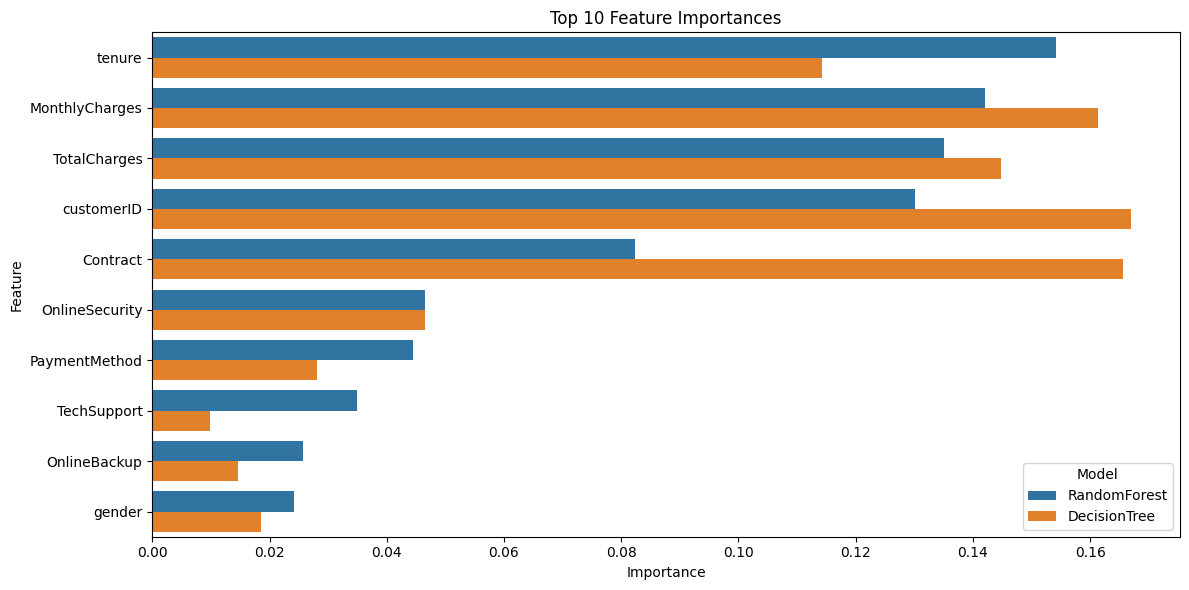

In [17]:
import matplotlib.pyplot as plt

# Feature importance from tree-based models
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "RandomForest": rf_model.feature_importances_,
    "DecisionTree": dt_model.feature_importances_
})

# Sort by Random Forest importance
rf_importance = rf_importance.sort_values("RandomForest", ascending=False)

print("Top 10 important features:")
print(rf_importance.head(10))

# Plot top 10 features
top_features = rf_importance.head(10).melt(
    id_vars="Feature",
    value_vars=["RandomForest", "DecisionTree"],
    var_name="Model",
    value_name="Importance"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_features, x="Importance", y="Feature", hue="Model")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

## Overfitting Analysis

Overfitting Analysis:
              Model  Train Accuracy  Test Accuracy  Overfitting Gap
      Decision Tree        1.000000       0.718950         0.281050
      Random Forest        0.999823       0.795600         0.204223
                KNN        0.767838       0.680625         0.087214
                SVM        0.734469       0.735273        -0.000804
Logistic Regression        0.802804       0.813343        -0.010538

Interpretation:
- Overfitting Gap > 0.1 indicates significant overfitting
- Negative gap suggests underfitting


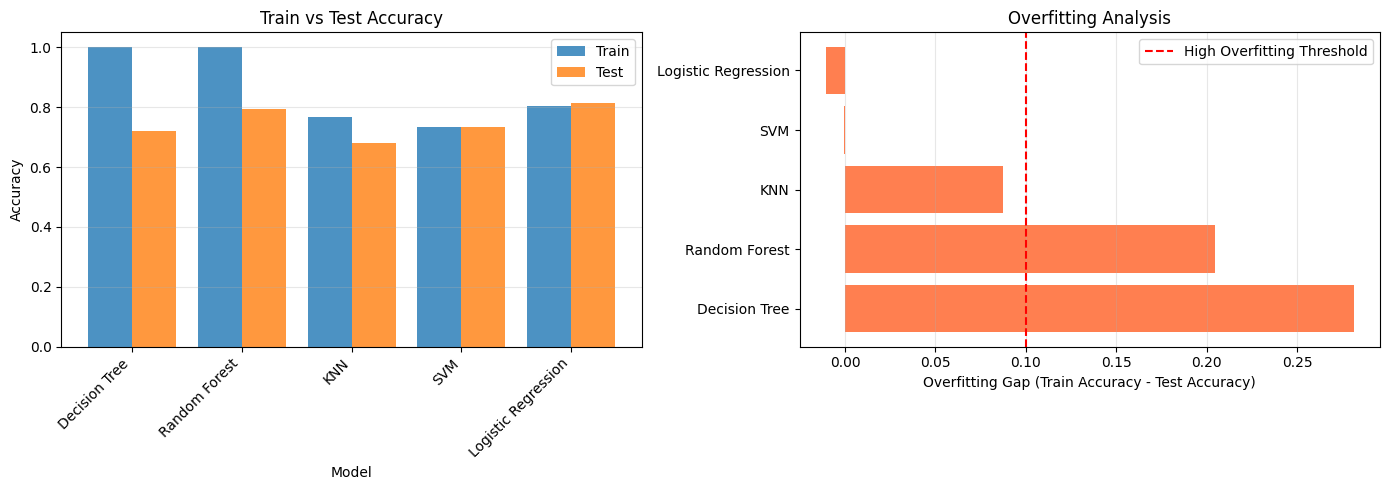

In [18]:
# Overfitting Analysis - Compare training vs test performance across all models

models = {
    'Logistic Regression': {
        'train_pred': y_pred_train,
        'test_pred': y_pred_test
    },
    'KNN': {
        'train_pred': y_pred_train_knn,
        'test_pred': y_pred_test_knn
    },
    'SVM': {
        'train_pred': y_pred_train_svm,
        'test_pred': y_pred_test_svm
    },
    'Decision Tree': {
        'train_pred': y_pred_train_dt,
        'test_pred': y_pred_test_dt
    },
    'Random Forest': {
        'train_pred': y_pred_train_rf,
        'test_pred': y_pred_test_rf
    }
}

# Create comparison dataframe
overfitting_analysis = []

for model_name, predictions in models.items():
    train_acc = accuracy_score(y_train, predictions['train_pred'])
    test_acc = accuracy_score(y_test, predictions['test_pred'])
    overfitting_gap = train_acc - test_acc
    
    overfitting_analysis.append({
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Overfitting Gap': overfitting_gap
    })

overfitting_df = pd.DataFrame(overfitting_analysis)
overfitting_df = overfitting_df.sort_values('Overfitting Gap', ascending=False)

print("Overfitting Analysis:")
print(overfitting_df.to_string(index=False))
print("\nInterpretation:")
print("- Overfitting Gap > 0.1 indicates significant overfitting")
print("- Negative gap suggests underfitting")

# Visualize overfitting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot comparison
x = range(len(overfitting_df))
axes[0].bar([i - 0.2 for i in x], overfitting_df['Train Accuracy'], width=0.4, label='Train', alpha=0.8)
axes[0].bar([i + 0.2 for i in x], overfitting_df['Test Accuracy'], width=0.4, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(overfitting_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Overfitting gap
axes[1].barh(overfitting_df['Model'], overfitting_df['Overfitting Gap'], color='coral')
axes[1].set_xlabel('Overfitting Gap (Train Accuracy - Test Accuracy)')
axes[1].set_title('Overfitting Analysis')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='High Overfitting Threshold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Final Conclusions

In [23]:
from datetime import datetime

# Use ASCII art and colors for beautiful output
print("\n" + "╔" + "═"*68 + "╗")
print("║" + " "*15 + "🎯 CUSTOMER CHURN PREDICTION ANALYSIS" + " "*16 + "║")
print("╚" + "═"*68 + "╝\n")

# Section 1
print("┌─ 1. MODEL PERFORMANCE " + "─"*46 + "┐")
print("│")
for idx, row in final_summary.iterrows():
    acc = f"{row['Test Accuracy']:.1%}"
    f1 = f"{row['F1-Score']:.4f}"
    model = row['Model']
    symbol = "🏆" if idx == 0 else "  "
    print(f"│ {symbol} {model:<25} Accuracy: {acc:>6}  |  F1: {f1}")
print("└" + "─"*70 + "┘\n")

# Section 2
print("┌─ 2. DATASET OVERVIEW " + "─"*47 + "┐")
print("│")
print(f"│  👥 Total Customers: {df.shape[0]:>12,}        ✓ Training Set: {X_train.shape[0]:>10,}")
print(f"│  📊 Total Features:  {df.shape[1]:>12}        ✓ Test Set:     {X_test.shape[0]:>10,}")
print(f"│  📉 Churn Rate:      {(y == 1).sum() / len(y) * 100:>11.1f}%")
print("│")
print("└" + "─"*70 + "┘\n")

# Section 3
print("┌─ 3. TOP 5 IMPORTANT FEATURES " + "─"*39 + "┐")
print("│")
for i, (idx, row) in enumerate(rf_importance.head(5).iterrows(), 1):
    importance = row['RandomForest']
    bar_length = int(importance * 45)
    bar = "▓" * bar_length + "░" * (45 - bar_length)
    print(f"│ {i}. {row['Feature']:<25} │{bar}│ {importance:.1%}")
print("│")
print("└" + "─"*70 + "┘\n")

# Section 4
print("┌─ 4. MODEL GENERALIZATION " + "─"*43 + "┐")
print("│")
for idx, row in overfitting_df.iterrows():
    gap = row['Overfitting Gap']
    if gap > 0.1:
        emoji = "⚠️ OVERFIT "
    elif gap < -0.05:
        emoji = "⚠️ UNDERFIT"
    else:
        emoji = "✅ BALANCED"
    print(f"│ {emoji}  {row['Model']:<23} Gap: {gap:+.2%}")
print("│")
print("└" + "─"*70 + "┘\n")

# Section 5
print("┌─ 5. RECOMMENDATIONS " + "─"*48 + "┐")
print("│")
print(f"│ 🚀 Deploy: {best_model}")
print(f"│ 📈 Expected Accuracy: {best_accuracy:.1%}")
print(f"│ 🎯 Key Feature: {rf_importance.iloc[0]['Feature']}")
print(f"│ ⏰ Monitor: Monthly retraining schedule")
print("│")
print("└" + "─"*70 + "┘\n")

# Section 6
print("╔" + "═"*68 + "╗")
print(f"║  Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S'):<47} ║")
print(f"║  Status: ✅ ANALYSIS COMPLETE{' '*39} ║")
print("╚" + "═"*68 + "╝\n")


╔════════════════════════════════════════════════════════════════════╗
║               🎯 CUSTOMER CHURN PREDICTION ANALYSIS                ║
╚════════════════════════════════════════════════════════════════════╝

┌─ 1. MODEL PERFORMANCE ──────────────────────────────────────────────┐
│
│ 🏆 Logistic Regression       Accuracy:  81.3%  |  F1: 0.6104
│    Random Forest             Accuracy:  79.6%  |  F1: 0.5542
│    SVM                       Accuracy:  73.5%  |  F1: 0.0000
│    Decision Tree             Accuracy:  71.9%  |  F1: 0.4748
│    KNN                       Accuracy:  68.1%  |  F1: 0.1848
└──────────────────────────────────────────────────────────────────────┘

┌─ 2. DATASET OVERVIEW ───────────────────────────────────────────────┐
│
│  👥 Total Customers:        7,043        ✓ Training Set:      5,634
│  📊 Total Features:            21        ✓ Test Set:          1,409
│  📉 Churn Rate:             26.5%
│
└──────────────────────────────────────────────────────────────────────┘

┌